# RT-DETR-L Training

## Config and Paths

In [1]:
import os

DATASET_YAML = '/home/achin/COS40007-Group/dataset/dataset.yaml'
WEIGHTS_PATH = '/home/achin/COS40007-Group/rtdetr-l.pt'
PROJECT_DIR  = '/home/achin/COS40007-Group/runs/defect_detection'
DATASET_ROOT = '/home/achin/COS40007-Group/dataset'

RUN = 'rtdetr_l_v4'
CLASS_NAMES = ['crack', 'pothole', 'wall_peeling']
BACKGROUND_PREFIXES = ('wall-', 'road-')
NC = 3
SPLITS = ['train', 'val', 'test']

IMAGE_DIRS = {s: os.path.join(DATASET_ROOT, s, 'images') for s in SPLITS}
LABEL_DIRS = {s: os.path.join(DATASET_ROOT, s, 'labels') for s in SPLITS}

print("Paths configured:")
for s in SPLITS:
    all_imgs = [f for f in os.listdir(IMAGE_DIRS[s]) if f.endswith('.jpg')]
    bg_imgs  = [f for f in all_imgs if f.startswith(BACKGROUND_PREFIXES)]
    def_imgs = [f for f in all_imgs if not f.startswith(BACKGROUND_PREFIXES)]
    print(f"  {s}: {len(def_imgs)} defect + {len(bg_imgs)} background = {len(all_imgs)} total")

Paths configured:
  train: 462 defect + 79 background = 541 total
  val: 99 defect + 18 background = 117 total
  test: 99 defect + 18 background = 117 total


## Dataset Exploratory Data Analysis


TRAIN: 541 images
  crack: 164 annotations
  pothole: 398 annotations
  wall_peeling: 233 annotations
  background (empty): 84 images
  bg/defect ratio: 0.11 ✅



VAL: 117 images
  crack: 34 annotations
  pothole: 82 annotations
  wall_peeling: 49 annotations
  background (empty): 18 images
  bg/defect ratio: 0.11 ✅



TEST: 117 images
  crack: 36 annotations
  pothole: 65 annotations
  wall_peeling: 47 annotations
  background (empty): 18 images
  bg/defect ratio: 0.12 ✅


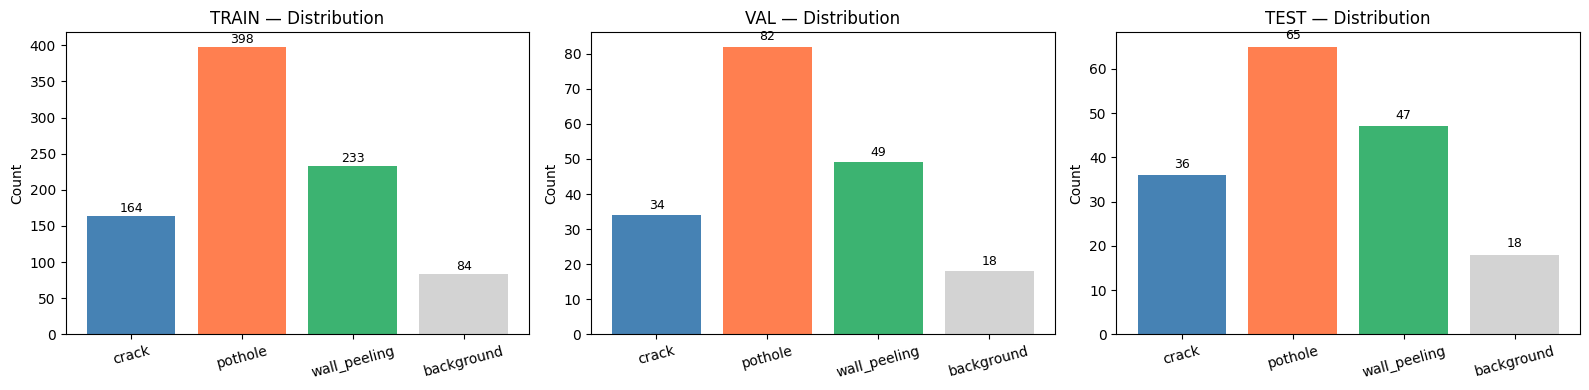

In [2]:
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt

def count_labels(split):
    label_dir = Path(LABEL_DIRS[split])
    class_counts = Counter()
    bg_count = 0
    for txt in label_dir.glob('*.txt'):
        content = txt.read_text().strip()
        if not content:
            bg_count += 1
        else:
            for line in content.splitlines():
                if line.strip():
                    cls = int(line.split()[0])
                    class_counts[cls] += 1
    return class_counts, bg_count

for split in SPLITS:
    counts, bg_count = count_labels(split)
    total_images = len(list(Path(IMAGE_DIRS[split]).glob('*.jpg')))
    print(f"\n{split.upper()}: {total_images} images")
    for cls_id in sorted(counts):
        print(f"  {CLASS_NAMES[cls_id]}: {counts[cls_id]} annotations")
    print(f"  background (empty): {bg_count} images")
    ratio = bg_count / max(sum(counts.values()), 1)
    print(f"  bg/defect ratio: {ratio:.2f} {'⚠️ consider reducing' if ratio > 0.5 else '✅'}")

# Bar chart — defect classes only, background shown separately
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, split in zip(axes, SPLITS):
    counts, bg_count = count_labels(split)
    names  = [CLASS_NAMES[i] for i in sorted(counts)] + ['background']
    values = [counts[i] for i in sorted(counts)] + [bg_count]
    colors = ['steelblue', 'coral', 'mediumseagreen', 'lightgray']
    bars = ax.bar(names, values, color=colors)
    ax.set_title(f'{split.upper()} — Distribution')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(val), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'class_distribution.png'), dpi=150)
plt.show()

## Visualise Sample Annotations

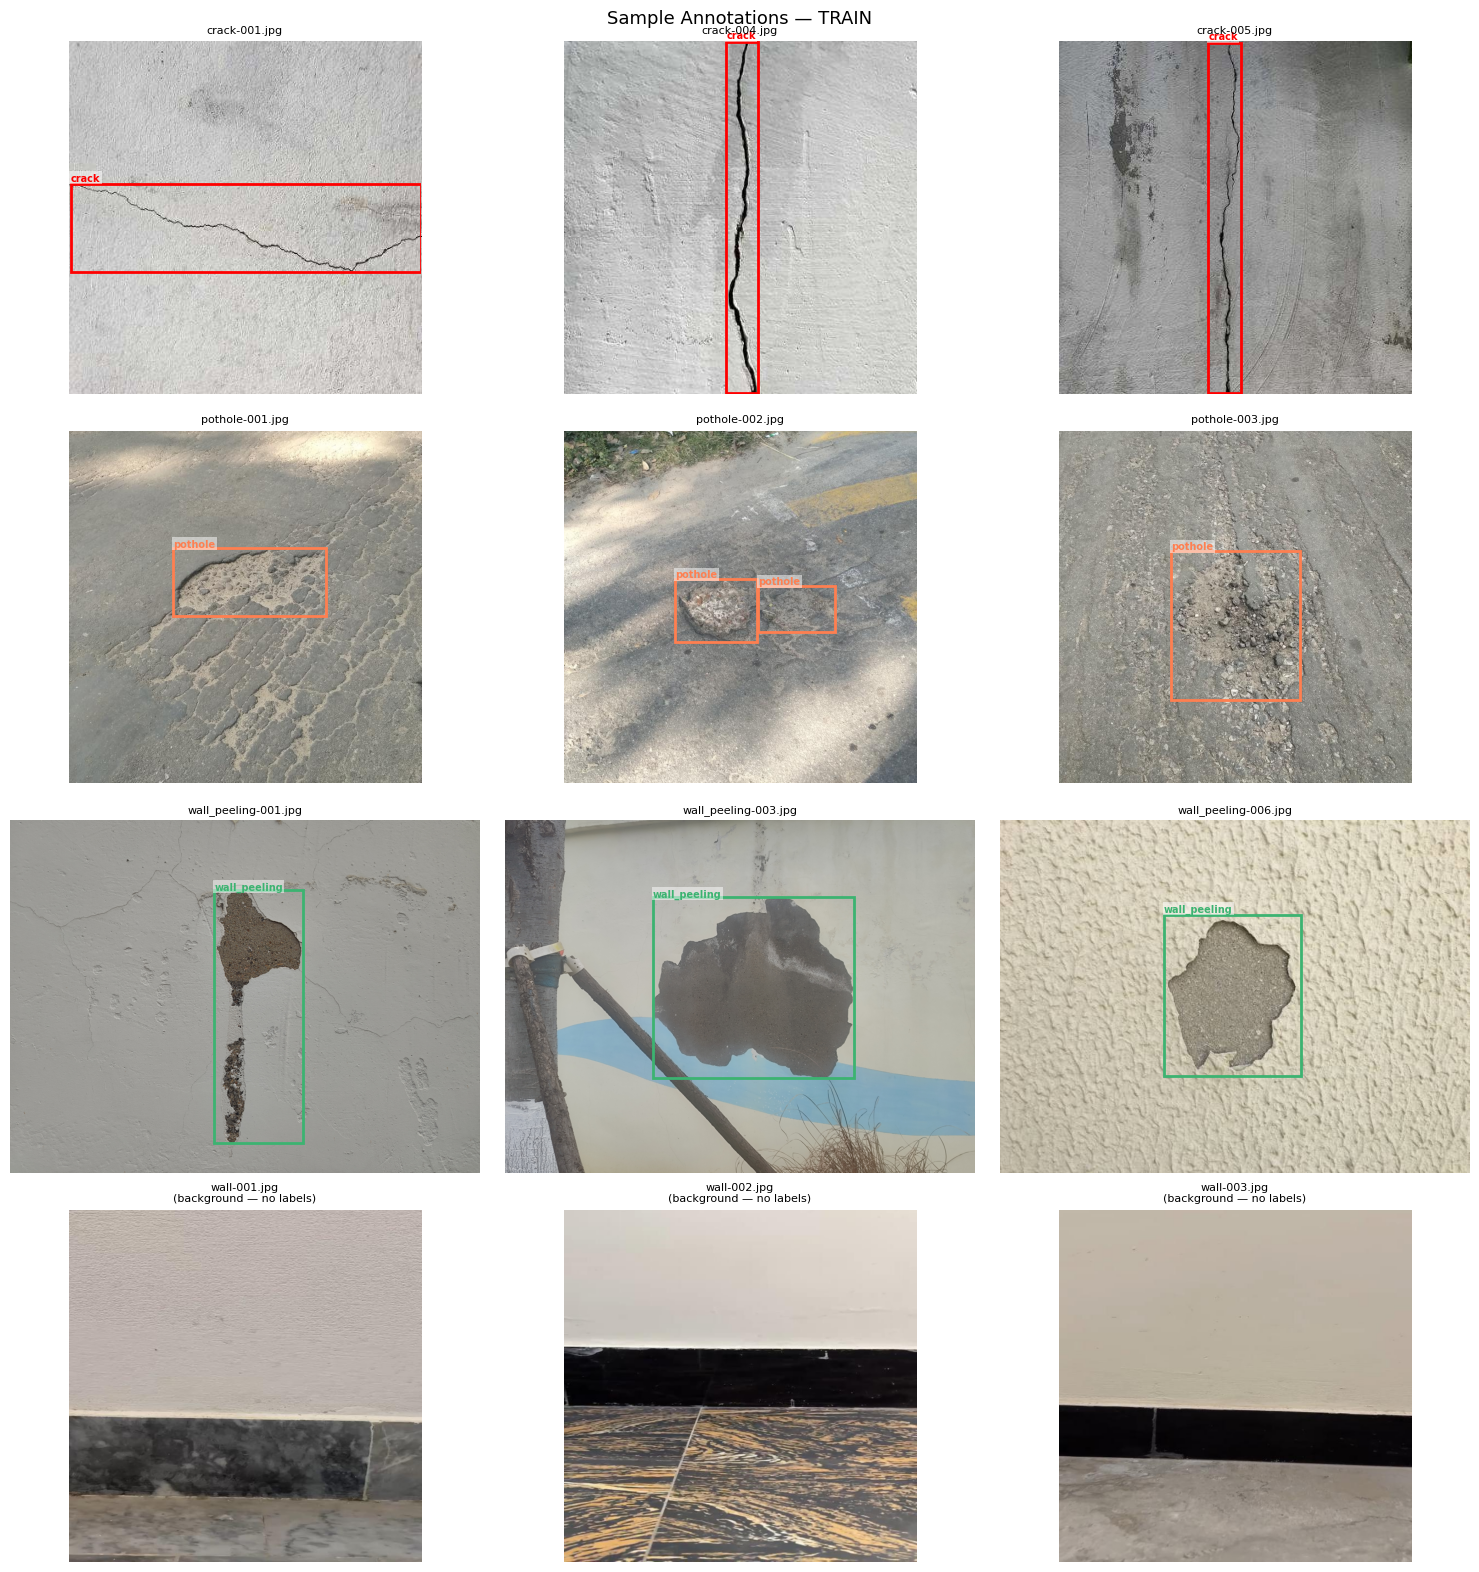

In [3]:
import matplotlib.patches as patches
from PIL import Image

def visualize_samples_by_class(split, n_per_class=3):
    img_dir = Path(IMAGE_DIRS[split])
    lbl_dir = Path(LABEL_DIRS[split])
    COLORS  = ['red', 'coral', 'mediumseagreen']

    # defect rows + 1 background row
    total_rows = NC + 1
    fig, axes = plt.subplots(total_rows, n_per_class, figsize=(5 * n_per_class, 4 * total_rows))

    # --- defect class rows ---
    for row, cls_name in enumerate(CLASS_NAMES):
        cls_imgs = sorted(img_dir.glob(f'{cls_name}-*.jpg'))[:n_per_class]

        for col in range(n_per_class):
            ax = axes[row][col]
            ax.axis('off')

            if col >= len(cls_imgs):
                ax.set_title(f'{cls_name} — no sample', fontsize=9)
                continue

            img_path = cls_imgs[col]
            img = Image.open(img_path).convert('RGB')
            w, h = img.size
            ax.imshow(img)
            ax.set_title(f'{img_path.name}', fontsize=8)

            lbl_path = lbl_dir / (img_path.stem + '.txt')
            if lbl_path.exists():
                for line in lbl_path.read_text().strip().splitlines():
                    parts = line.split()
                    if not parts:
                        continue
                    c, cx, cy, bw, bh = int(parts[0]), float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                    x1 = (cx - bw/2) * w
                    y1 = (cy - bh/2) * h
                    rect = patches.Rectangle(
                        (x1, y1), bw*w, bh*h,
                        linewidth=2, edgecolor=COLORS[c % len(COLORS)], facecolor='none'
                    )
                    ax.add_patch(rect)
                    ax.text(x1, y1 - 4, CLASS_NAMES[c], color=COLORS[c % len(COLORS)],
                            fontsize=7, fontweight='bold',
                            bbox=dict(facecolor='white', alpha=0.5, pad=1, edgecolor='none'))

    bg_imgs = []
    for prefix in BACKGROUND_PREFIXES:
        bg_imgs.extend(sorted(img_dir.glob(f'{prefix}*.jpg')))
    bg_imgs = bg_imgs[:n_per_class]

    for col in range(n_per_class):
        ax = axes[NC][col]
        ax.axis('off')
        if col < len(bg_imgs):
            img = Image.open(bg_imgs[col]).convert('RGB')
            ax.imshow(img)
            ax.set_title(f'{bg_imgs[col].name}\n(background — no labels)', fontsize=8)
        else:
            ax.set_title('background — no sample', fontsize=9)

    plt.suptitle(f'Sample Annotations — {split.upper()}', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(PROJECT_DIR, f'sample_annotations_{split}.png'), dpi=150)
    plt.show()

visualize_samples_by_class('train', n_per_class=3)

## Training

In [4]:
from pathlib import Path

for split in SPLITS:
    cache = Path(LABEL_DIRS[split]).parent / 'labels.cache'
    if cache.exists():
        cache.unlink()
        print(f"Deleted cache: {cache}")
    else:
        print(f"No cache found for {split} — OK")

Deleted cache: /home/achin/COS40007-Group/dataset/train/labels.cache
Deleted cache: /home/achin/COS40007-Group/dataset/val/labels.cache
No cache found for test — OK


In [5]:
from ultralytics import RTDETR

os.makedirs(PROJECT_DIR, exist_ok=True)

model = RTDETR(WEIGHTS_PATH)

results = model.train(
    data=DATASET_YAML,
    epochs=300,
    imgsz=640,
    batch=16,
    lr0=1e-4,
    lrf=0.001,
    warmup_epochs=5,
    warmup_bias_lr=0.1,
    optimizer='AdamW',
    weight_decay=1e-4,
    patience=50,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    fliplr=0.5,
    flipud=0.1,
    scale=0.5,
    mosaic=1.0,
    copy_paste=0.3,
    degrees=10.0,
    translate=0.1,
    workers=16,
    save=True,
    plots=True,
    amp=False,
    device=0,
    project=PROJECT_DIR,
    name=RUN,
    exist_ok=True,
)

print("Training complete.")
print(f"Best weights saved to: {PROJECT_DIR}/{RUN}/weights/best.pt")

Ultralytics 8.4.56 🚀 Python-3.9.25 torch-2.8.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)


engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/achin/COS40007-Group/dataset/dataset.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=300, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.001, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/home/achin/COS40007-Group/rtdetr-l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=rtdetr_l_v4, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=50, perspective=0.0, plots=True,

Overriding model.yaml nc=80 with nc=3


WARNING ⚠️ no model scale passed. Assuming scale='l'.



                   from  n    params  module                                       arguments                     


...

              potholes         33         82      0.735      0.707      0.704      0.413


          wall_peeling         33         49      0.729      0.735      0.718      0.409


Speed: 0.1ms preprocess, 6.5ms inference, 0.0ms loss, 0.8ms postprocess per image


Results saved to /home/achin/COS40007-Group/runs/defect_detection/rtdetr_l_v4


Training complete.
Best weights saved to: /home/achin/COS40007-Group/runs/defect_detection/rtdetr_l_v4/weights/best.pt


## Validation on Val Set

In [6]:
best_weights = os.path.join(PROJECT_DIR, RUN, 'weights', 'best.pt')
trained_model = RTDETR(best_weights)

val_metrics = trained_model.val(
    data=DATASET_YAML,
    split='val',
    plots=True,
    save_json=True,
    project=PROJECT_DIR,
    name=f'{RUN}_val',
    exist_ok=True,
)

print("\n--- Val Metrics ---")
print(f"mAP@50:     {val_metrics.box.map50:.4f}")
print(f"mAP@50-95:  {val_metrics.box.map:.4f}")
print(f"Precision:  {val_metrics.box.mp:.4f}")
print(f"Recall:     {val_metrics.box.mr:.4f}")
print(f"\nPer-class AP@50:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {val_metrics.box.ap50[i]:.4f}")

Ultralytics 8.4.56 🚀 Python-3.9.25 torch-2.8.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)


rt-detr-l summary: 310 layers, 31,989,905 parameters, 0 gradients, 103.4 GFLOPs


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 654.9±348.7 MB/s, size: 49.1 KB)


val: Scanning /home/achin/COS40007-Group/dataset/val/labels.cache... 117 images, 18 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 117/117 18.9Mit/s 0.0s

/home/achin/COS40007-Group/.venv/lib64/python3.9/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


...

          wall_peeling         33         49      0.733      0.735      0.718      0.408


Speed: 0.6ms preprocess, 7.3ms inference, 0.0ms loss, 0.3ms postprocess per image


Saving /home/achin/COS40007-Group/runs/defect_detection/rtdetr_l_v4_val/predictions.json...


Results saved to /home/achin/COS40007-Group/runs/defect_detection/rtdetr_l_v4_val



--- Val Metrics ---
mAP@50:     0.5872
mAP@50-95:  0.3186
Precision:  0.6694
Recall:     0.5956

Per-class AP@50:
  crack: 0.3391
  pothole: 0.7040
  wall_peeling: 0.7184


## Evaluation on Test Set

In [7]:
test_metrics = trained_model.val(
    data=DATASET_YAML,
    split='test',
    plots=True,
    project=PROJECT_DIR,
    name=f'{RUN}_test',
    exist_ok=True,
)

print("\n--- Test Metrics ---")
print(f"mAP@50:     {test_metrics.box.map50:.4f}")
print(f"mAP@50-95:  {test_metrics.box.map:.4f}")
print(f"Precision:  {test_metrics.box.mp:.4f}")
print(f"Recall:     {test_metrics.box.mr:.4f}")
print(f"\nPer-class AP@50:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {test_metrics.box.ap50[i]:.4f}")

Ultralytics 8.4.56 🚀 Python-3.9.25 torch-2.8.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)


rt-detr-l summary: 310 layers, 31,989,905 parameters, 0 gradients, 103.4 GFLOPs


val: Fast image access ✅ (ping: 0.5±0.1 ms, read: 31.2±27.7 MB/s, size: 44.7 KB)


val: Scanning /home/achin/COS40007-Group/dataset/test/labels... 117 images, 18 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 117/117 1.6Kit/s 0.1s

val: New cache created: /home/achin/COS40007-Group/dataset/test/labels.cache


...

              potholes         33         65      0.793      0.646      0.644      0.391


          wall_peeling         33         47      0.761      0.743      0.712      0.416


Speed: 1.0ms preprocess, 6.6ms inference, 0.0ms loss, 0.4ms postprocess per image


Results saved to /home/achin/COS40007-Group/runs/defect_detection/rtdetr_l_v4_test



--- Test Metrics ---
mAP@50:     0.5692
mAP@50-95:  0.2919
Precision:  0.6769
Recall:     0.5395

Per-class AP@50:
  crack: 0.3519
  pothole: 0.6436
  wall_peeling: 0.7121


## Training Curves

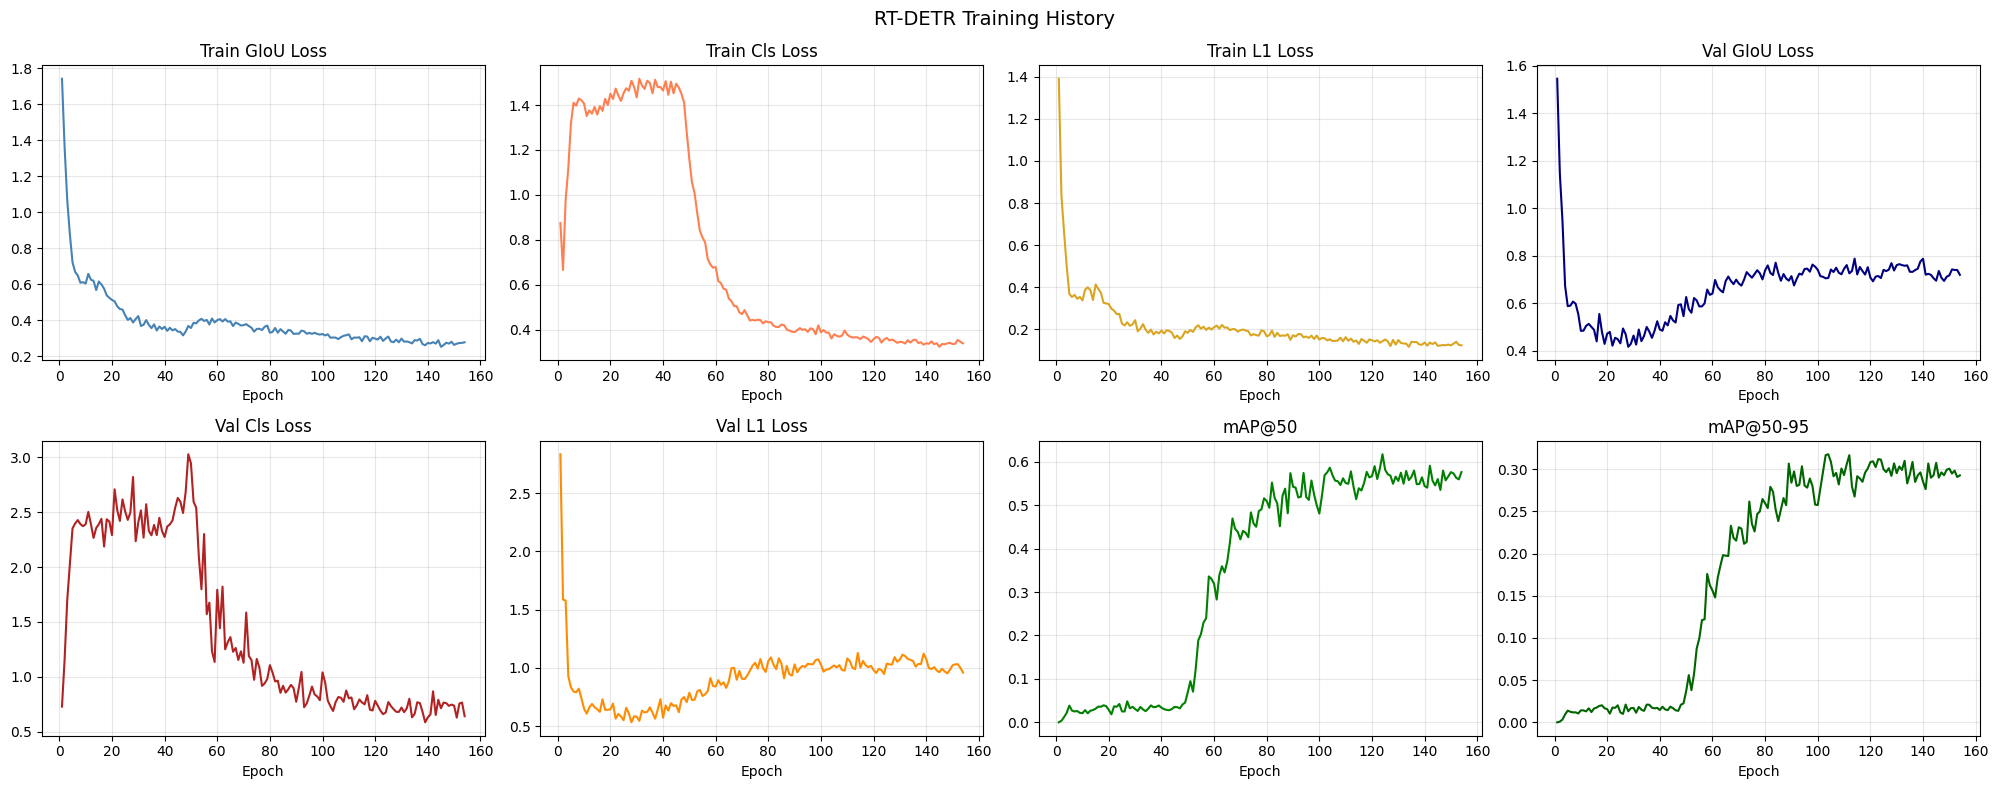

In [8]:
import pandas as pd
import matplotlib.image as mpimg

results_csv = os.path.join(PROJECT_DIR, RUN, 'results.csv')
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

plots = [
    ('train/giou_loss',       'Train GIoU Loss',  'steelblue'),
    ('train/cls_loss',        'Train Cls Loss',   'coral'),
    ('train/l1_loss',         'Train L1 Loss',    'goldenrod'),
    ('val/giou_loss',         'Val GIoU Loss',    'navy'),
    ('val/cls_loss',          'Val Cls Loss',     'firebrick'),
    ('val/l1_loss',           'Val L1 Loss',      'darkorange'),
    ('metrics/mAP50(B)',      'mAP@50',           'green'),
    ('metrics/mAP50-95(B)',   'mAP@50-95',        'darkgreen'),
    ('metrics/precision(B)',  'Precision',        'purple'),
    ('metrics/recall(B)',     'Recall',           'orange'),
    ('lr/pg0',                'LR (backbone)',    'gray'),
    ('lr/pg1',                'LR (weights)',     'darkgray'),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, (col, title, color) in zip(axes.flatten(), plots):
    if col in df.columns:
        ax.plot(df['epoch'], df[col], color=color, linewidth=1.5)
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.grid(True, alpha=0.3)
    else:
        ax.set_title(f'{title} (not found)')
        ax.axis('off')

plt.suptitle('RT-DETR Training History', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'training_curves.png'), dpi=150)
plt.show()

## Inference and Visualisation on Test Images

image 1/117 /home/achin/COS40007-Group/dataset/test/images/crack-002.jpg: 640x640 2 cracks, 2 wall_peelings, 19.0ms


image 2/117 /home/achin/COS40007-Group/dataset/test/images/crack-003.jpg: 640x640 2 cracks, 19.5ms


image 3/117 /home/achin/COS40007-Group/dataset/test/images/crack-008.jpg: 640x640 1 crack, 18.5ms


image 4/117 /home/achin/COS40007-Group/dataset/test/images/crack-013.jpg: 640x640 1 crack, 18.4ms


image 5/117 /home/achin/COS40007-Group/dataset/test/images/crack-018.jpg: 640x640 1 crack, 18.5ms


...

image 115/117 /home/achin/COS40007-Group/dataset/test/images/wall_peeling-200.jpg: 640x640 3 wall_peelings, 18.4ms


image 116/117 /home/achin/COS40007-Group/dataset/test/images/wall_peeling-211.jpg: 640x640 6 potholess, 2 wall_peelings, 18.4ms


image 117/117 /home/achin/COS40007-Group/dataset/test/images/wall_peeling-213.jpg: 640x640 2 wall_peelings, 18.5ms


Speed: 1.7ms preprocess, 18.8ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)


Results saved to /home/achin/COS40007-Group/runs/defect_detection/rtdetr_l_v4_predictions


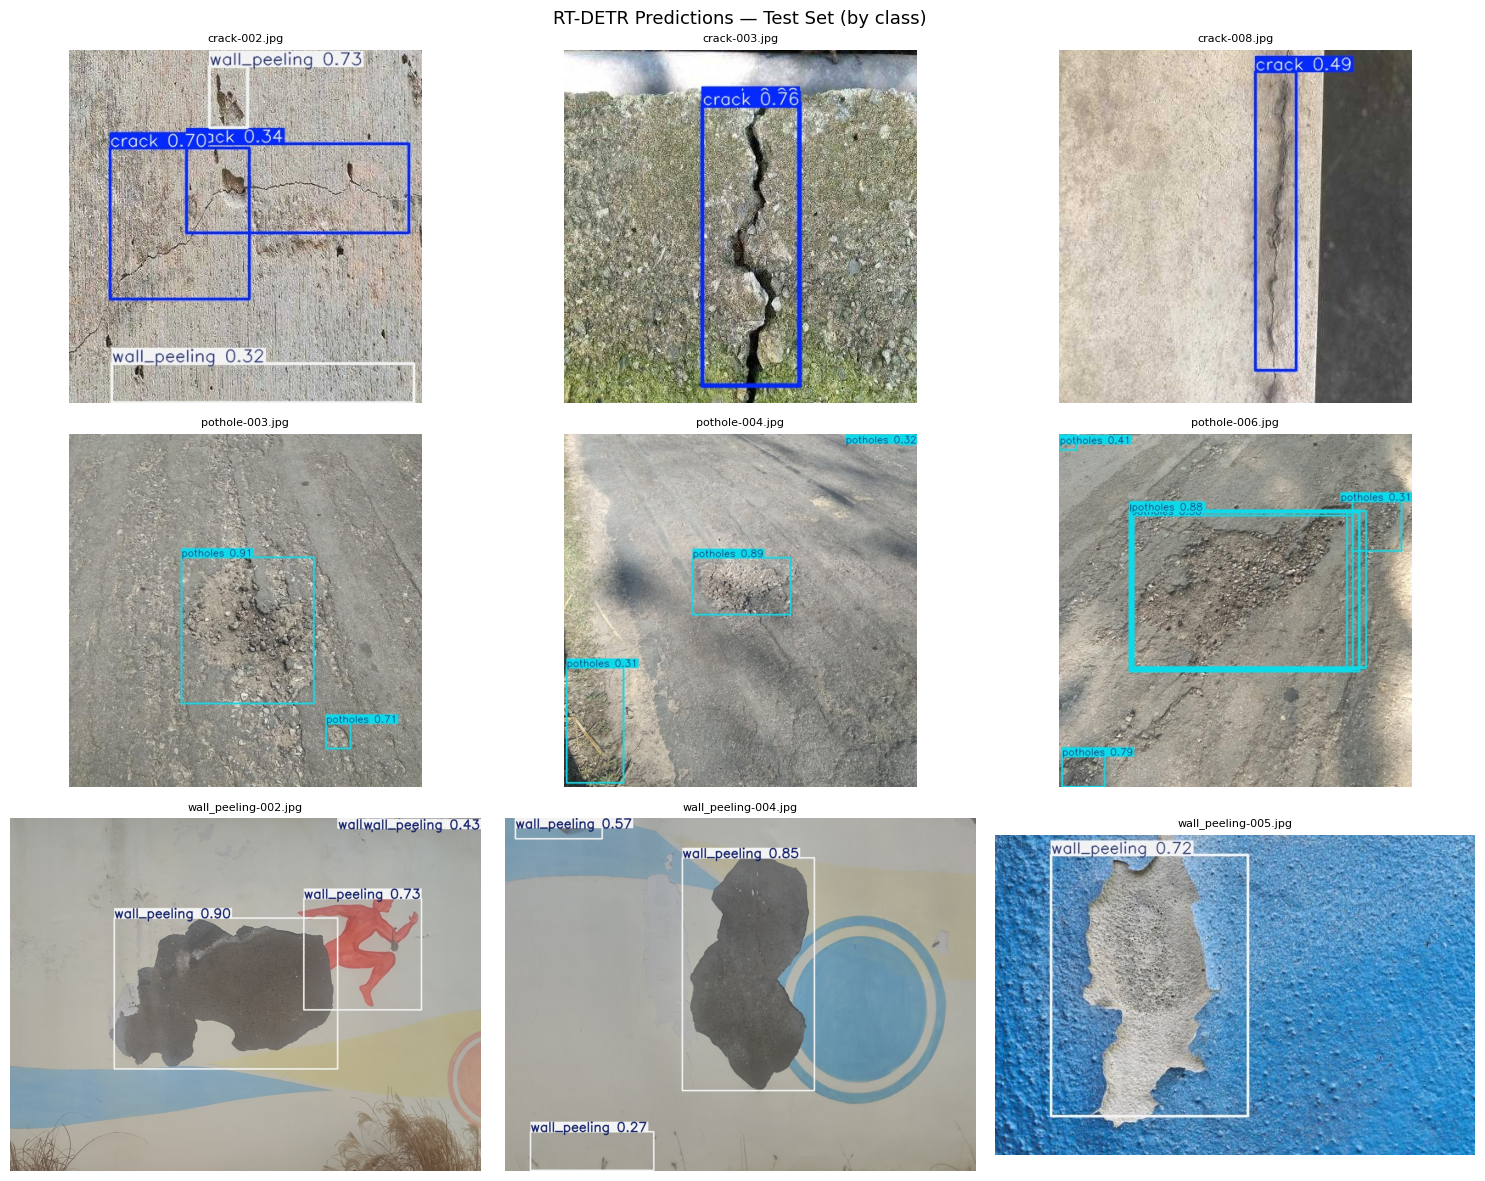

In [9]:
trained_model.predict(
    source=IMAGE_DIRS['test'],
    conf=0.25,
    iou=0.5,
    save=True,
    project=PROJECT_DIR,
    name=f'{RUN}_predictions',
    exist_ok=True,
)

pred_dir = Path(PROJECT_DIR) / f'{RUN}_predictions'

fig, axes = plt.subplots(NC, 3, figsize=(15, 4 * NC))
for row, cls_name in enumerate(CLASS_NAMES):
    cls_preds = sorted(pred_dir.glob(f'{cls_name}-*.jpg'))[:3]
    for col in range(3):
        ax = axes[row][col]
        ax.axis('off')
        if col < len(cls_preds):
            ax.imshow(mpimg.imread(cls_preds[col]))
            ax.set_title(cls_preds[col].name, fontsize=8)
        else:
            ax.set_title(f'{cls_name} — no prediction saved', fontsize=8)

plt.suptitle('RT-DETR Predictions — Test Set (by class)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'prediction_samples.png'), dpi=150)
plt.show()

## Display Evaluation Plots

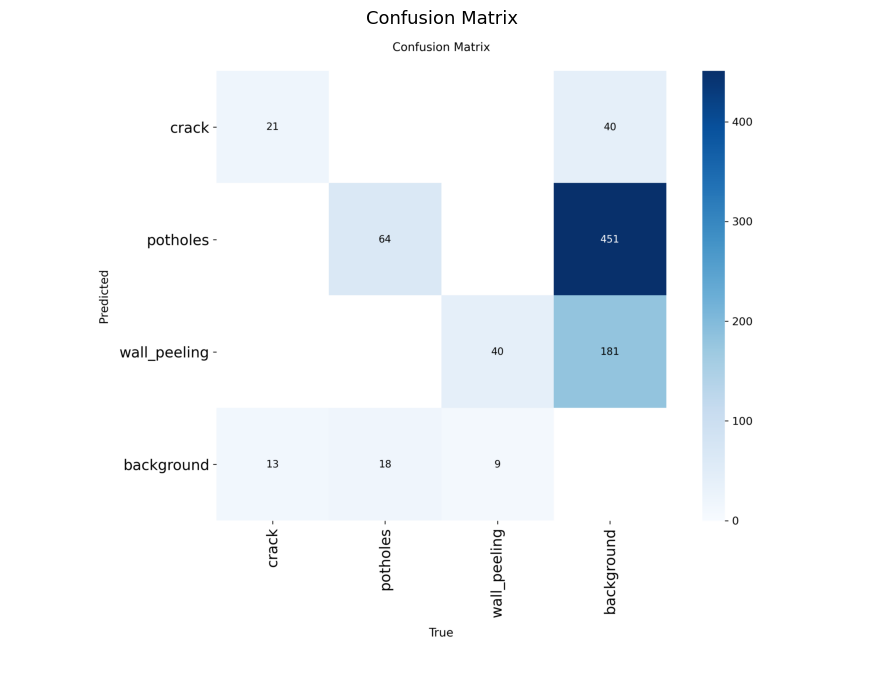

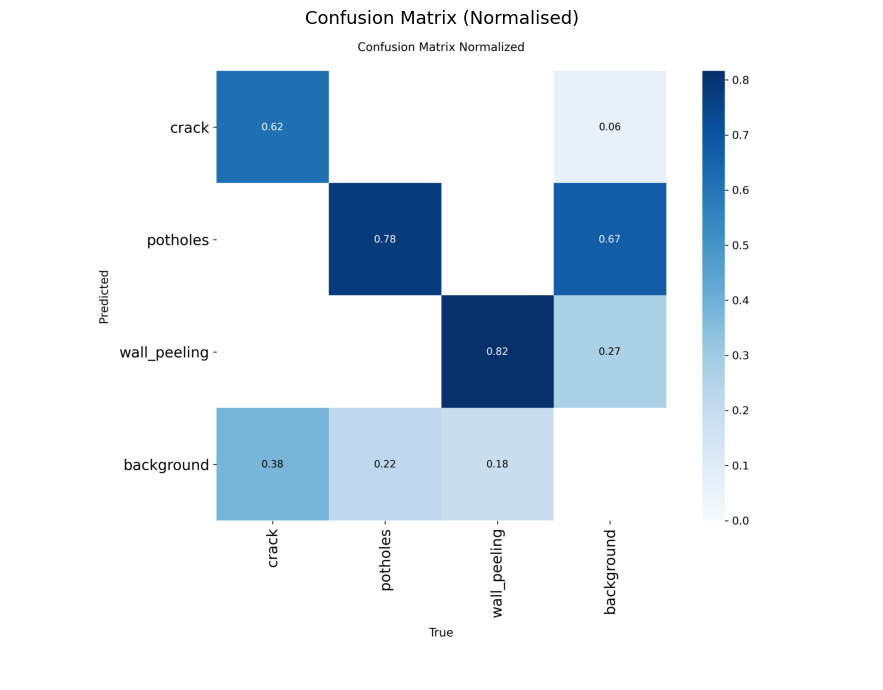

Not yet generated: PR_curve.png
Not yet generated: P_curve.png
Not yet generated: R_curve.png


In [10]:
eval_plots = [
    ('confusion_matrix.png',            'Confusion Matrix'),
    ('confusion_matrix_normalized.png', 'Confusion Matrix (Normalised)'),
    ('PR_curve.png',                    'Precision-Recall Curve'),
    ('P_curve.png',                     'Precision Curve'),
    ('R_curve.png',                     'Recall Curve'),
]

run_dir = Path(PROJECT_DIR) / RUN

for filename, title in eval_plots:
    p = run_dir / filename
    if p.exists():
        plt.figure(figsize=(10, 7))
        plt.imshow(mpimg.imread(p))
        plt.title(title, fontsize=13)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print(f"Not yet generated: {filename}")

## Inference Speed Benchmark

In [11]:
import time

test_imgs = list(Path(IMAGE_DIRS['test']).glob('*.jpg'))[:50]

# Warmup
trained_model.predict(source=[str(test_imgs[0])], conf=0.25, verbose=False)

# Timed run
start = time.time()
trained_model.predict(source=[str(p) for p in test_imgs], conf=0.25, verbose=False)
elapsed = time.time() - start

fps = len(test_imgs) / elapsed
print(f"Images tested : {len(test_imgs)}")
print(f"Total time    : {elapsed:.2f}s")
print(f"FPS           : {fps:.1f}")
print(f"ms/image      : {1000/fps:.1f}")

Images tested : 50
Total time    : 0.77s
FPS           : 65.2
ms/image      : 15.3


## Display Evaluation Plots

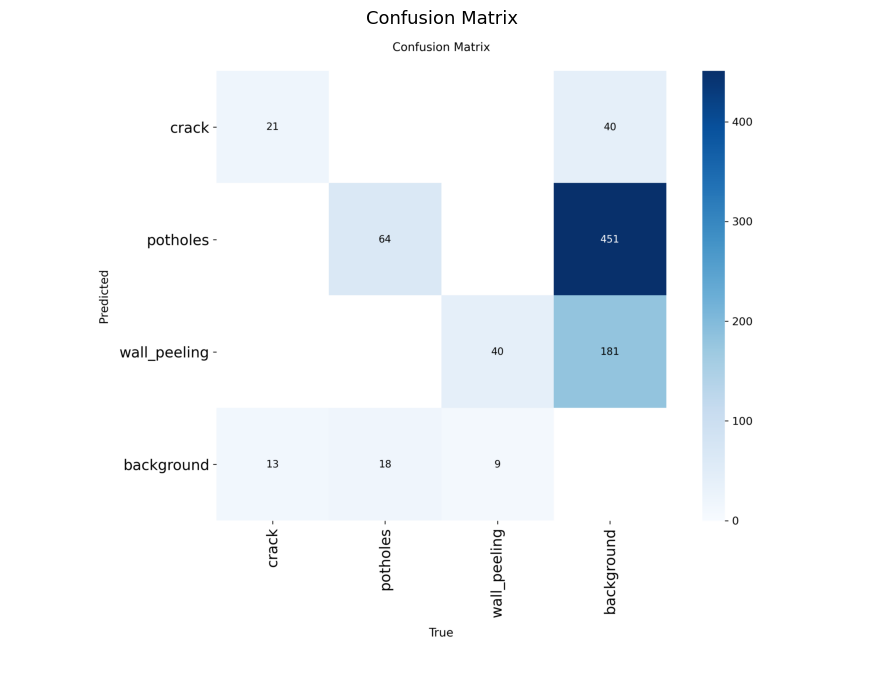

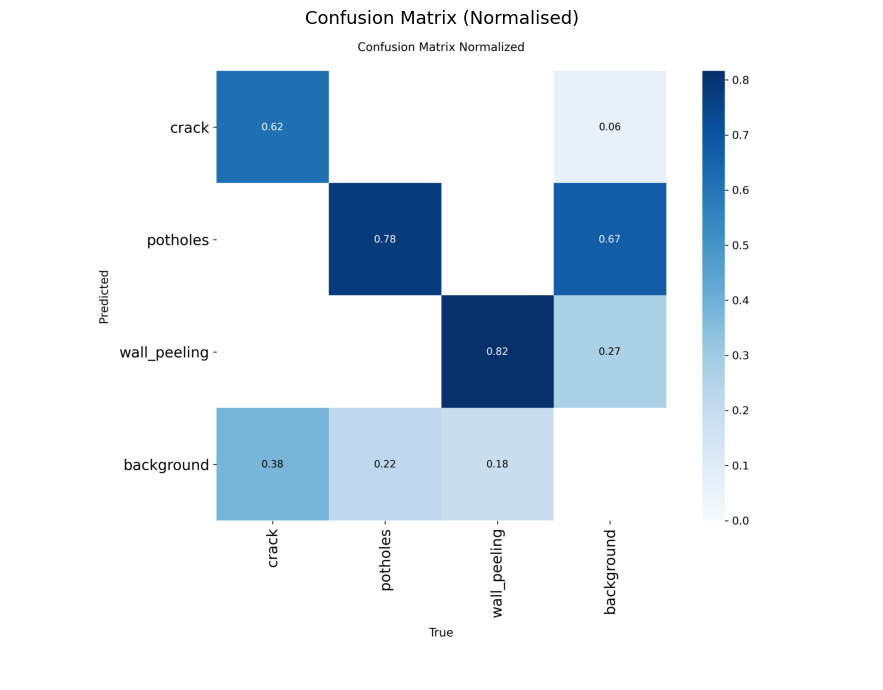

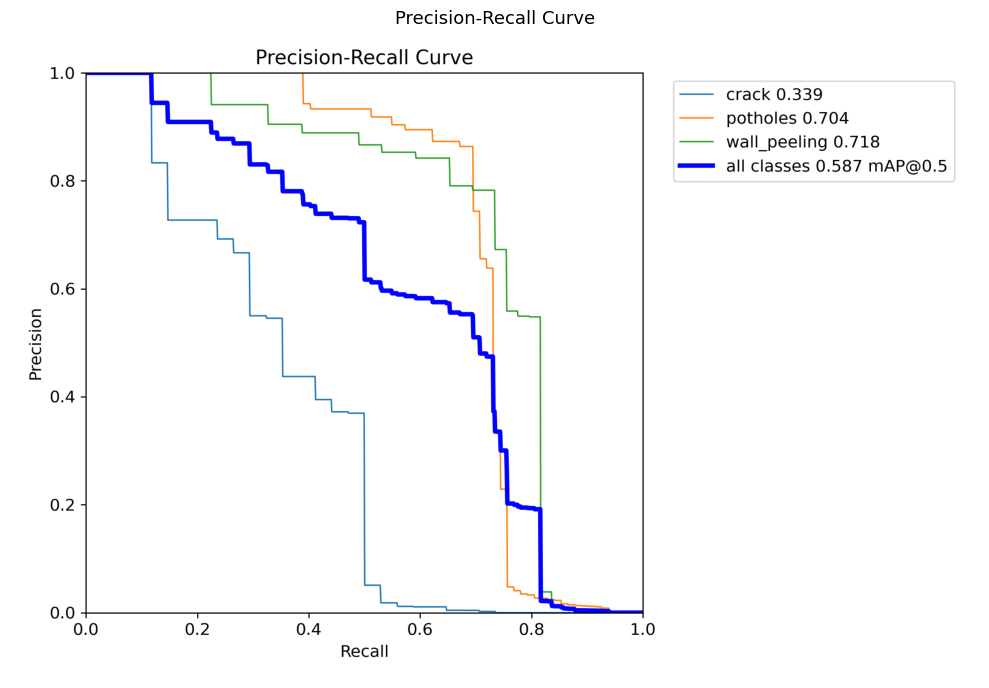

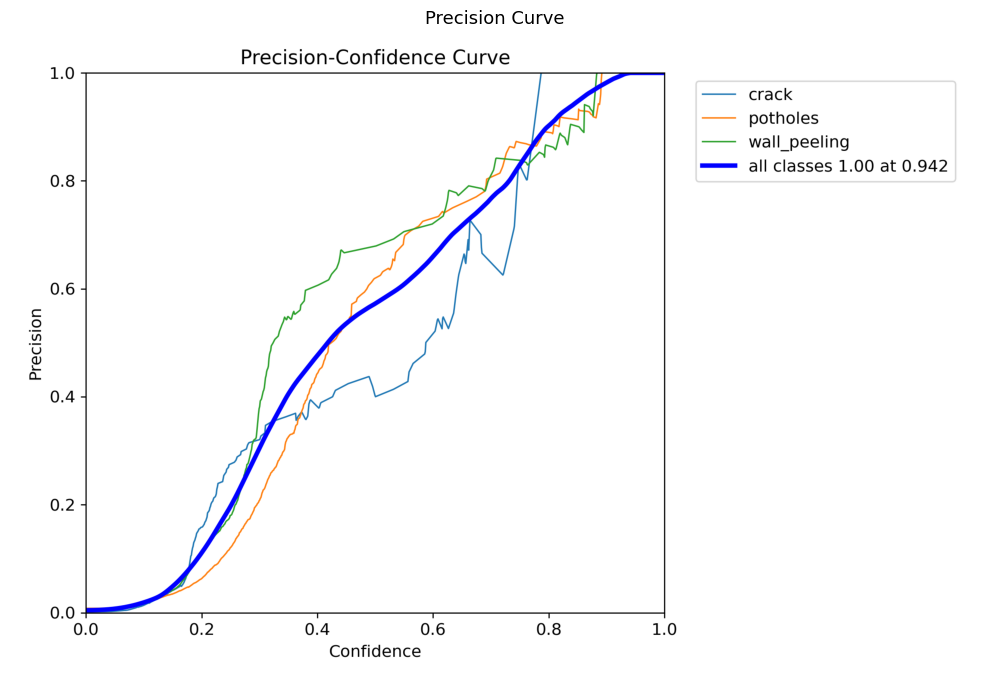

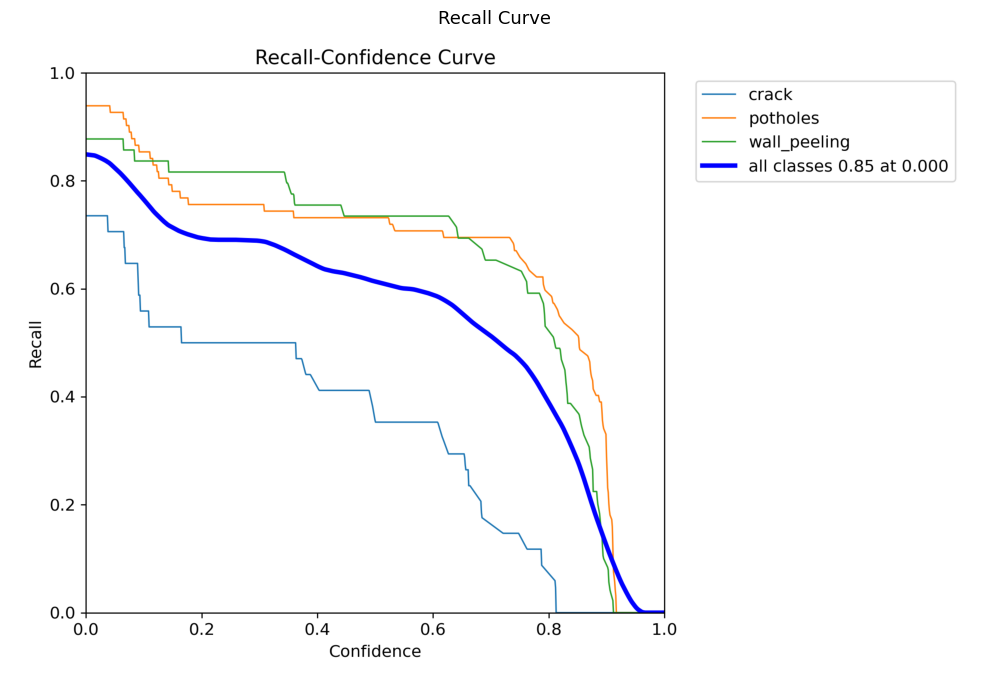

In [12]:
eval_plots = [
    ('confusion_matrix.png',            'Confusion Matrix'),
    ('confusion_matrix_normalized.png', 'Confusion Matrix (Normalised)'),
    ('BoxPR_curve.png',                    'Precision-Recall Curve'),
    ('BoxP_curve.png',                     'Precision Curve'),
    ('BoxR_curve.png',                     'Recall Curve'),
]

run_dir = Path(PROJECT_DIR) / RUN

for filename, title in eval_plots:
    p = run_dir / filename
    if p.exists():
        plt.figure(figsize=(10, 7))
        plt.imshow(mpimg.imread(p))
        plt.title(title, fontsize=13)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print(f"Not yet generated: {filename}")